In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

from utils.mapping import SERIES_NAME_MAPPING, SERIES_NAME_MAPPING_2, EXPERIMENT_NAME_PLOT_MAPPING, EXPERIMENT_NAME_PLOT_MAPPING_2
from utils.plotTools import saving_manager, darken_color, format_time, format_time_label

In [39]:
results_dir = r'..\results'
dirs_to_ignore = ['archive']
plot_dir = fr'..\plots\global_overview'

should_save = True
make_it_fancy = True

In [40]:
all_data_temporal = []
all_data_simulation = []
all_data_volcanic = []

for experiment_name in os.listdir(results_dir):
    if experiment_name in dirs_to_ignore:
        continue
    experiment_path = os.path.join(results_dir, experiment_name)
    if os.path.isdir(experiment_path):
        experiment_id = experiment_name
        for run_name in os.listdir(experiment_path):
            run_path = os.path.join(experiment_path, run_name)
            if os.path.isdir(run_path):
                run_id = run_name
                file_temporal = os.path.join(run_path, 'temporal_series_recorder.csv')
                file_simulation = os.path.join(run_path, 'simulation_recorder.csv')
                file_volcanic = os.path.join(run_path, 'volcanic_recorder.csv')
                if os.path.exists(file_temporal):
                    df_temporal = pd.read_csv(file_temporal)
                    df_temporal['run_id'] = run_id
                    df_temporal['experiment_id'] = experiment_id
                    all_data_temporal.append(df_temporal)

                    df_simulation = pd.read_csv(file_simulation)
                    df_simulation['run_id'] = run_id
                    df_simulation['experiment_id'] = experiment_id
                    all_data_simulation.append(df_simulation)

                    df_volcanic = pd.read_csv(file_volcanic)
                    df_volcanic['run_id'] = run_id
                    df_volcanic['experiment_id'] = experiment_id
                    all_data_volcanic.append(df_volcanic)

temporal_df = pd.concat(all_data_temporal, ignore_index=True)
simulation_df = pd.concat(all_data_simulation, ignore_index=True)
volcanic_df = pd.concat(all_data_volcanic, ignore_index=True)

with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(simulation_df.head(100))

print(temporal_df['experiment_id'].unique())

    event_time                                     event_name                                              notes run_id        experiment_id
0            0                       Volcanic Activity Update     Volcano LaFossawent from activity level 1 to 2    0.2     ITAlert_Emotions
1         1798  Population Evacuation Order - IT Alert issued  Civil defense ordered evacuation of civil popu...    0.2     ITAlert_Emotions
2         1799                        Backups Reached Vulcano  30 backup LEAs arrived on the Island. Ordered ...    0.2     ITAlert_Emotions
3        37470                          LEAs Evacuation Order  Civil defense ordered evacuation of Law Enforc...    0.2     ITAlert_Emotions
4        41169                     Civil Evacuation Completed  The evacuation of civil population was completed.    0.2     ITAlert_Emotions
..         ...                                            ...                                                ...    ...                  ...
95       2044

In [41]:
simulation_df['event_time'] = pd.to_numeric(simulation_df['event_time'])
grouped = simulation_df.groupby(['experiment_id', 'run_id'])

time_data = []

for (experiment_id, run_id), group_df in grouped:
    pop_evac_time_series = group_df[group_df['event_name'].str.contains('Population Evacuation Order', na=False, regex=False)]['event_time']
    civil_evac_completed_time_series = group_df[group_df['event_name'] == 'Civil Evacuation Completed']['event_time']
    evac_completed_time_series = group_df[group_df['event_name'] == 'Evacuation Completed']['event_time']

    pop_evac_time = pop_evac_time_series.iloc[0] if not pop_evac_time_series.empty else None
    civil_evac_completed_time = civil_evac_completed_time_series.iloc[0] if not civil_evac_completed_time_series.empty else None
    evac_completed_time = evac_completed_time_series.iloc[0] if not evac_completed_time_series.empty else None

    civil_evac_duration = (civil_evac_completed_time - pop_evac_time) if pop_evac_time is not None and civil_evac_completed_time is not None else None
    evac_duration = (evac_completed_time - pop_evac_time) if pop_evac_time is not None and evac_completed_time is not None else None

    time_data.append({
        'experiment_id': experiment_id,
        'run_id': run_id,
        'Civil Evacuation Duration': civil_evac_duration,
        'Full Evacuation Duration': evac_duration,
    })

time_df = pd.DataFrame(time_data)

In [42]:
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(time_df.head(10))

      experiment_id              run_id  Civil Evacuation Duration  Full Evacuation Duration
0  ITAlert_Emotions                 0.2                      39371                     40413
1  ITAlert_Emotions                 0.4                      29748                     33146
2  ITAlert_Emotions  0.6000000000000001                      32299                     33268
3  ITAlert_Emotions                 0.8                      26284                     27331
4  ITAlert_Emotions                 1.0                      26994                     29931
5  ITAlert_Emotions                 1.2                      40211                     41249
6  ITAlert_Emotions                 1.4                      42033                     43093
7  ITAlert_Emotions  1.5999999999999999                      34126                     36943
8  ITAlert_Emotions  1.7999999999999998                      28562                     30075
9  ITAlert_Emotions  1.9999999999999998                      69925    

In [43]:
summary_df = time_df.groupby('experiment_id').agg(
    Mean_Civil_Evacuation_Time=('Civil Evacuation Duration', 'mean'),
    Std_Civil_Evacuation_Time=('Civil Evacuation Duration', 'std'),
    Mean_Full_Evacuation_Time=('Full Evacuation Duration', 'mean'),
    Std_Full_Evacuation_Time=('Full Evacuation Duration', 'std')
).reset_index()

time_df = pd.merge(time_df, summary_df, on='experiment_id', how='left')

if should_save:
    if not os.path.exists(plot_dir):
        os.makedirs(plot_dir, exist_ok=True)
    time_df.to_csv(os.path.join(plot_dir,'time.csv')) 

In [44]:
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(time_df.head(10))

      experiment_id              run_id  Civil Evacuation Duration  Full Evacuation Duration  Mean_Civil_Evacuation_Time  Std_Civil_Evacuation_Time  Mean_Full_Evacuation_Time  Std_Full_Evacuation_Time
0  ITAlert_Emotions                 0.2                      39371                     40413                     36955.3               12885.832927                    38634.4              12513.041847
1  ITAlert_Emotions                 0.4                      29748                     33146                     36955.3               12885.832927                    38634.4              12513.041847
2  ITAlert_Emotions  0.6000000000000001                      32299                     33268                     36955.3               12885.832927                    38634.4              12513.041847
3  ITAlert_Emotions                 0.8                      26284                     27331                     36955.3               12885.832927                    38634.4              12513.04

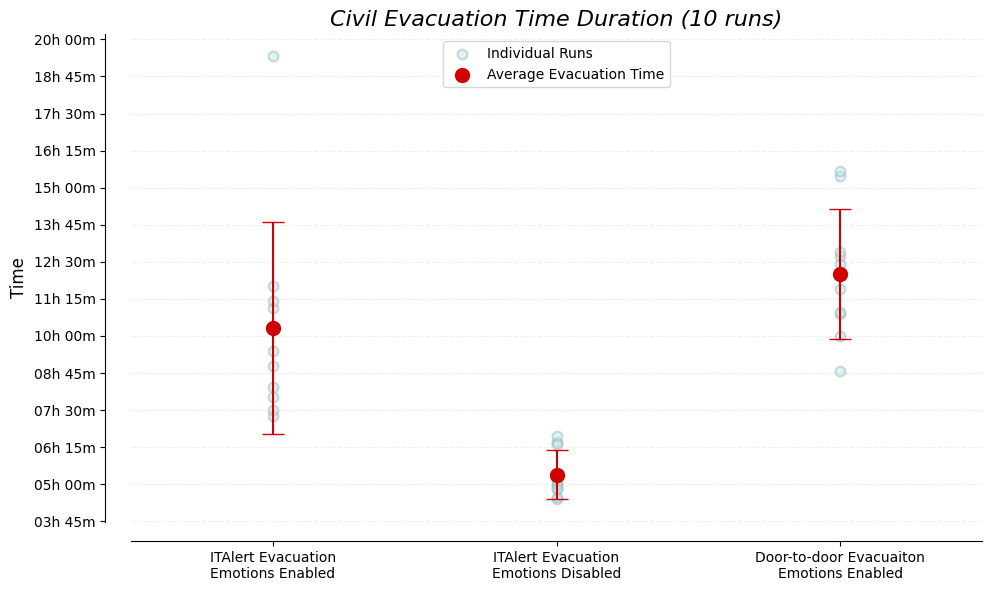

Plot saved here: ..\plots\global_overview\civil_evacuation_duration.png


In [45]:
plot_filename = 'civil_evacuation_duration.png'

time_format = "hh mm"

single_run_color = "#bee9e8"
avg_color = '#d00000'

fig, ax = plt.subplots(figsize=(10, 6))

x_positions = {}
for i, experiment_name in enumerate(time_df['experiment_id'].unique()):
    x_positions[experiment_name] = i + 1

time_df['x_pos'] = time_df['experiment_id'].map(x_positions)

scatter_handle = ax.scatter(
    x=time_df['x_pos'],
    y=time_df['Civil Evacuation Duration'],
    marker = 'o',
    s=50,
    edgecolor=darken_color(single_run_color),
    linewidth=1.5,
    alpha=0.5,
    color=single_run_color,
    label='Individual Runs'
)

avg_points_handle = ax.scatter(
    x=time_df.groupby('experiment_id')['x_pos'].first(),
    y=time_df.groupby('experiment_id')['Mean_Civil_Evacuation_Time'].first(),
    marker='o',
    s=100,
    color=avg_color,
    label='' 
)

error_bars_handle = ax.errorbar(
    x=time_df.groupby('experiment_id')['x_pos'].first(),
    y=time_df.groupby('experiment_id')['Mean_Civil_Evacuation_Time'].first(),
    yerr=time_df.groupby('experiment_id')['Std_Civil_Evacuation_Time'].first(),
    fmt='none',  
    capsize=8,
    color=avg_color,
    label=''
)


ax.set_title('Civil Evacuation Time Duration (10 runs)', fontsize=16, fontstyle='italic')

x_tick_labels = time_df['experiment_id'].unique()
x_tick_positions = [x_positions[label] for label in x_tick_labels]
actual_x_tick_labels = [EXPERIMENT_NAME_PLOT_MAPPING.get(label, label) for label in x_tick_labels]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(actual_x_tick_labels)
time_formatter = lambda t, pos: format_time(t, format=time_format)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(time_formatter))
tick_interval = 4500
ax.yaxis.set_major_locator(mticker.MultipleLocator(tick_interval))

handles = [scatter_handle, avg_points_handle]
labels = ['Individual Runs', 'Average Evacuation Time']
ax.legend(handles, labels, loc='upper center')
# ax.set_xlabel('Experiment ID', fontsize=12)
ax.set_ylabel('Time', fontsize=12)
ax.set_xlim(0.5, time_df['x_pos'].max()+0.5)
if make_it_fancy:
    ax = plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['bottom'].set_position(('axes', -0.04))
    ax.spines['left'].set_position(('axes', -0.03))

ax.grid(True, axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()
plot_filepath=os.path.join(plot_dir, plot_filename)
saving_manager(should_save=should_save, save_path=plot_filepath, should_show=True)

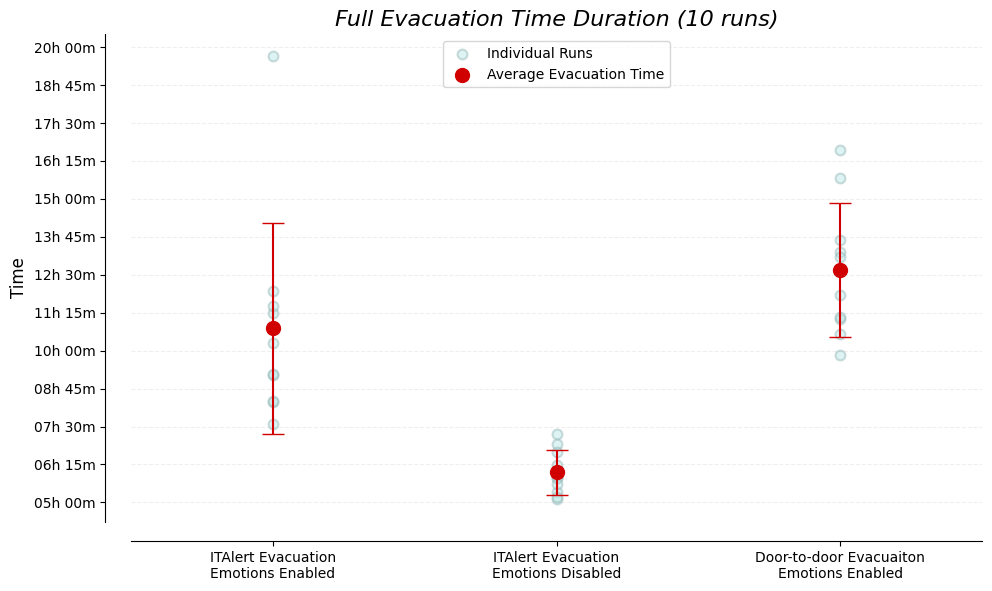

Plot saved here: ..\plots\global_overview\full_evacuation_duration.png


In [46]:
plot_filename = 'full_evacuation_duration.png'

single_run_color = "#bee9e8"
avg_color = '#d00000'

fig, ax = plt.subplots(figsize=(10, 6))

x_positions = {}
for i, experiment_name in enumerate(time_df['experiment_id'].unique()):
    x_positions[experiment_name] = i + 1

time_df['x_pos'] = time_df['experiment_id'].map(x_positions)

scatter_handle = ax.scatter(
    x=time_df['x_pos'],
    y=time_df['Full Evacuation Duration'],
    marker = 'o',
    s=50,
    edgecolor=darken_color(single_run_color),
    linewidth=1.5,
    alpha=0.5,
    color=single_run_color,
    label='Individual Runs'
)

avg_points_handle = ax.scatter(
    x=time_df.groupby('experiment_id')['x_pos'].first(),
    y=time_df.groupby('experiment_id')['Mean_Full_Evacuation_Time'].first(),
    marker='o',
    s=100,
    color=avg_color,
    label='' 
)

error_bars_handle = ax.errorbar(
    x=time_df.groupby('experiment_id')['x_pos'].first(),
    y=time_df.groupby('experiment_id')['Mean_Full_Evacuation_Time'].first(),
    yerr=time_df.groupby('experiment_id')['Std_Full_Evacuation_Time'].first(),
    fmt='none',  
    capsize=8,
    color=avg_color,
    label=''
)


ax.set_title('Full Evacuation Time Duration (10 runs)', fontsize=16, fontstyle='italic')

x_tick_labels = time_df['experiment_id'].unique()
x_tick_positions = [x_positions[label] for label in x_tick_labels]
actual_x_tick_labels = [EXPERIMENT_NAME_PLOT_MAPPING.get(label, label) for label in x_tick_labels]
ax.set_xticks(x_tick_positions)
ax.set_xticklabels(actual_x_tick_labels)
time_formatter = lambda t, pos: format_time(t, format=time_format)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(time_formatter))
tick_interval = 4500
ax.yaxis.set_major_locator(mticker.MultipleLocator(tick_interval))

handles = [scatter_handle, avg_points_handle]
labels = ['Individual Runs', 'Average Evacuation Time']
ax.legend(handles, labels, loc='upper center')
# ax.set_xlabel('Experiment ID', fontsize=12)
ax.set_ylabel('Time', fontsize=12)
ax.set_xlim(0.5, time_df['x_pos'].max()+0.5)
if make_it_fancy:
    ax = plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['bottom'].set_position(('axes', -0.04))
    ax.spines['left'].set_position(('axes', -0.03))

ax.grid(True, axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()
plot_filepath=os.path.join(plot_dir, plot_filename)
saving_manager(should_save=should_save, save_path=plot_filepath, should_show=True)

In [54]:
unique_runs_and_exps = temporal_df[['experiment_id', 'run_id']].drop_duplicates()
max_time = temporal_df['time'].max()
all_times = pd.Series(range(0, int(max_time)+1), name='time')
all_combinations = unique_runs_and_exps.merge(all_times, how='cross')
extended_temporal_df = pd.merge(
    all_combinations,
    temporal_df,
    on=['experiment_id', 'run_id', 'time'],
    how='left'
)

# Sort the DataFrame for better readability
extended_temporal_df = extended_temporal_df.sort_values(by=['experiment_id', 'run_id', 'time']).reset_index(drop=True)

In [59]:
column_of_interest = "nb_people_on_island"

extended_temporal_df[column_of_interest] = extended_temporal_df[column_of_interest].fillna(0)

# reduced_temporal_df = temporal_df[["time", column_of_interest, "run_id", "experiment_id"]].copy()
reduced_temporal_df = extended_temporal_df[["time", column_of_interest, "run_id", "experiment_id"]].copy()
avg_df = reduced_temporal_df.groupby(['experiment_id', 'time'])['nb_people_on_island'].mean().reset_index()
avg_df = avg_df.rename(columns={column_of_interest: f"avg_{column_of_interest}"})


In [60]:
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(reduced_temporal_df)
    print(avg_df)

          time  nb_people_on_island              run_id        experiment_id
0            0                500.0                 0.2     ITAlert_Emotions
1            1                500.0                 0.2     ITAlert_Emotions
2            2                500.0                 0.2     ITAlert_Emotions
3            3                500.0                 0.2     ITAlert_Emotions
4            4                500.0                 0.2     ITAlert_Emotions
...        ...                  ...                 ...                  ...
2180815  72689                  0.0  1.9999999999999998  No_ITAlert_Emotions
2180816  72690                  0.0  1.9999999999999998  No_ITAlert_Emotions
2180817  72691                  0.0  1.9999999999999998  No_ITAlert_Emotions
2180818  72692                  0.0  1.9999999999999998  No_ITAlert_Emotions
2180819  72693                  0.0  1.9999999999999998  No_ITAlert_Emotions

[2180820 rows x 4 columns]
              experiment_id   time  avg_nb_peopl

In [61]:
multiple_line_plots_dict = {
    'people_overview': {
        'columns': ['nb_people_on_island', ],
        'title': "People on Island Overview",
        'filename': "people_on_island_overview",
        'ylabel': "People",
    },
}

end_of_run_color = "#757575"
experiment_color = {
    "ITAlert_Emotions": "#1B9E77",
    "ITAlert_No_Emotions": "#D96F02",
    "No_ITAlert_Emotions": "#757083",
}


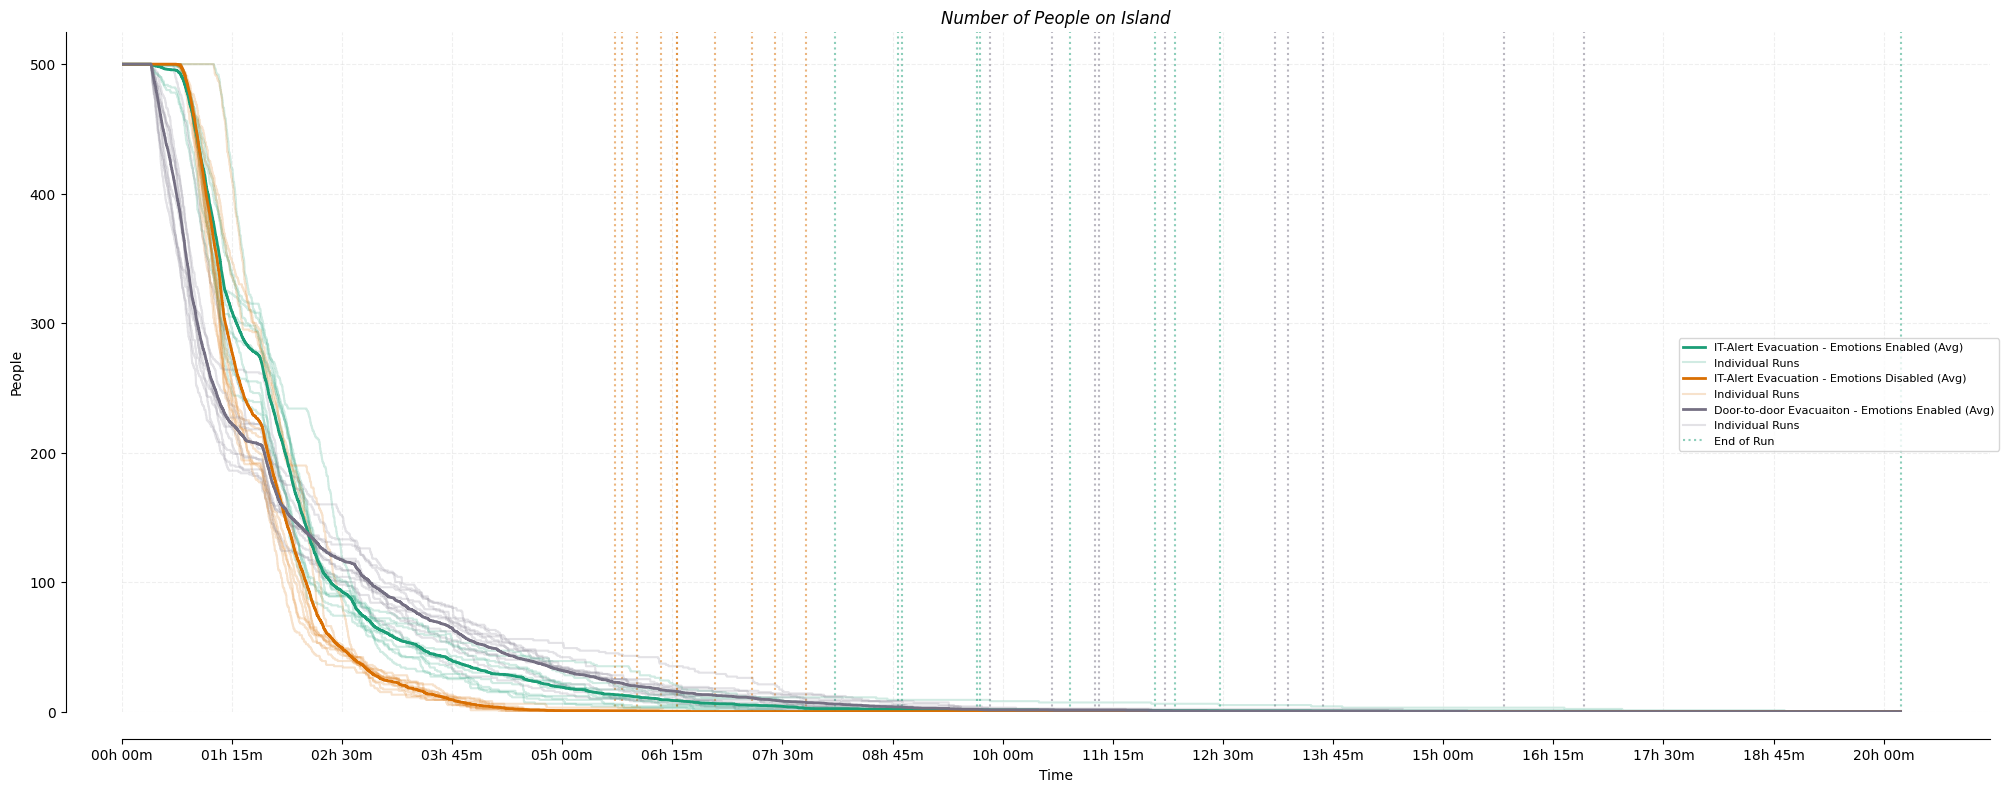

Plot saved here: ..\plots\global_overview\people_on_island_overview_sl_subplots_fancy_long.png


In [67]:
selected_plot = 'people_overview'

plot_dict = multiple_line_plots_dict[selected_plot]
columns_to_plot = plot_dict['columns']

n_subplots = len(columns_to_plot)
fig, axes = plt.subplots(1, n_subplots, figsize=(20, 8), sharey=True)

# fig.suptitle(plot_dict['title'], fontsize=16)

handles = []
labels = []
vline_handle = None
individual_run_handle = None

for i, column in enumerate(columns_to_plot):
    if len(columns_to_plot) > 1:
        ax = axes[i]
    else:
        ax = axes
    
    first_run_line = True
    for experiment_id in temporal_df['experiment_id'].unique():
        temporal_df_filtered = temporal_df[temporal_df['experiment_id'] == experiment_id]
        avg_df_filtered = avg_df[avg_df['experiment_id'] == experiment_id]
        
        first_run_line = True
        for run_id in temporal_df_filtered['run_id'].unique():
            run_df = temporal_df_filtered[temporal_df_filtered['run_id'] == run_id]
            line, = ax.plot(run_df['time'], run_df[column], color=experiment_color[experiment_id], linestyle='-', alpha=0.2, zorder=1)
            if first_run_line:
                individual_run_handle = line
                first_run_line = False
        
        mean_line, = ax.plot(avg_df_filtered['time'], avg_df_filtered[f"avg_{column}"], color=experiment_color[experiment_id], linewidth=2, zorder=2)
        
        handles.append(mean_line)
        labels.append(f'{EXPERIMENT_NAME_PLOT_MAPPING_2[experiment_id]} (Avg)')
        
        df_max_time = temporal_df_filtered.groupby('run_id')['time'].max()
        for run_id, max_time in df_max_time.items():
            if vline_handle is None:
                vline_handle = ax.axvline(x=max_time, color=experiment_color[experiment_id], linestyle=':', alpha=0.5, label='End of Run', zorder=0)
            else:
                ax.axvline(x=max_time, color=experiment_color[experiment_id], linestyle=':', alpha=0.5, zorder=0)
        
        handles.append(individual_run_handle)
        labels.append('Individual Runs')
    
    ax.set_title(f'{SERIES_NAME_MAPPING[column]}', fontsize=12, fontstyle='italic')
    ax.set_xlim(0, temporal_df['time'].max()*1.05)
    # ax.set_xlim(0, 36000*1.05)
    ax.set_ylim(0)
    time_formatter = lambda t, pos: format_time(t, format=time_format)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(time_formatter))
    tick_interval = 4500
    ax.xaxis.set_major_locator(mticker.MultipleLocator(tick_interval))
    format_time_label(ax, fontsize=10, format=time_format)

    ax.grid(True, linestyle='--', alpha=0.2)
    
    if i == 0:
        ax.set_ylabel(plot_dict['ylabel'], fontsize=10)

handles.append(vline_handle)
labels.append('End of Run')

if make_it_fancy:
    if len(columns_to_plot) > 1:
        for ax in axes:
            ax.spines['right'].set_color('none')
            ax.spines['top'].set_color('none')
            ax.xaxis.set_ticks_position('bottom')
            ax.yaxis.set_ticks_position('left')
            ax.spines['bottom'].set_position(('axes', -0.04))
            ax.spines['left'].set_position(('axes', -0.03))
    else:
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        ax.spines['bottom'].set_position(('axes', -0.04))
        ax.spines['left'].set_position(('axes', -0.03))

fig.legend(handles, labels, loc='right', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()

if make_it_fancy:
    plot_filename = plot_dict['filename'] + "_sl_subplots_fancy_long.png"
else:
    plot_filename = plot_dict['filename'] + "_sl_subplots_long.png"

plot_filepath = os.path.join(plot_dir, plot_filename)
saving_manager(should_save=should_save, save_path=plot_filepath, should_show=True)